In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/final.csv")
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
1,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
2,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
3,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
4,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY


In [13]:
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 16896 entries, 0 to 16895
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16896 non-null  float64
 1   latitude            16896 non-null  float64
 2   housing_median_age  16896 non-null  float64
 3   total_rooms         16896 non-null  float64
 4   total_bedrooms      16896 non-null  float64
 5   population          16896 non-null  float64
 6   households          16896 non-null  float64
 7   median_income       16896 non-null  float64
 8   median_house_value  16896 non-null  float64
 9   ocean_proximity     16896 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.3 MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,16896.000000,16896.000000,16896.000000,16896.000000,16896.000000,16896.000000,16896.000000,16896.000000,16896.000000
mean,-119.613767,35.714332,29.666785,2071.883049,426.848307,1149.646899,399.439394,3.576432,185341.761127
std,2.005735,2.173749,12.210209,1025.323863,199.477046,549.764399,186.177008,1.446000,92053.652162
min,-124.350000,32.540000,1.000000,2.000000,2.000000,3.000000,2.000000,0.499900,14999.000000
25%,-121.782500,33.940000,19.000000,1346.000000,283.000000,753.000000,267.000000,2.482100,112500.000000
50%,-118.700000,34.400000,30.000000,1931.000000,404.000000,1086.000000,379.000000,3.395400,169050.000000
75%,-118.030000,37.750000,38.000000,2686.000000,553.250000,1505.000000,520.000000,4.500000,240500.000000
max,-114.490000,41.950000,52.000000,5688.000000,1044.000000,2721.000000,908.000000,8.015800,458300.000000


In [14]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)


Numeric: Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='str')
Categorical: Index(['ocean_proximity'], dtype='str')


/tmp/ipykernel_886308/3406610708.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns


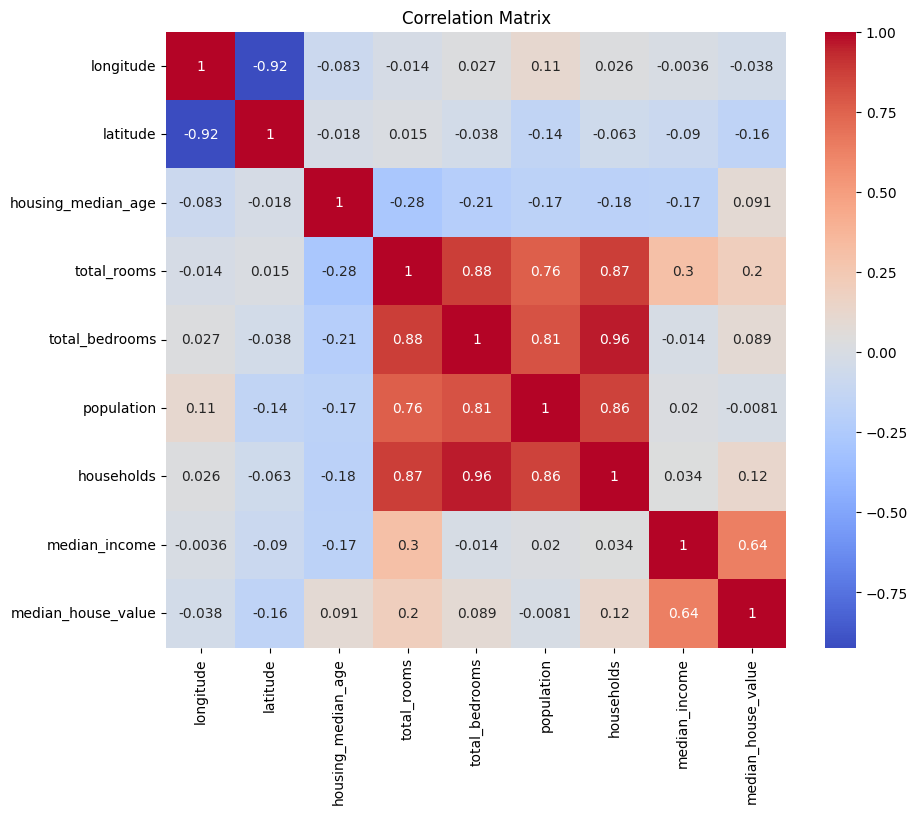

In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_features].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.savefig('../logs/correlation_matrix.png')
plt.show()


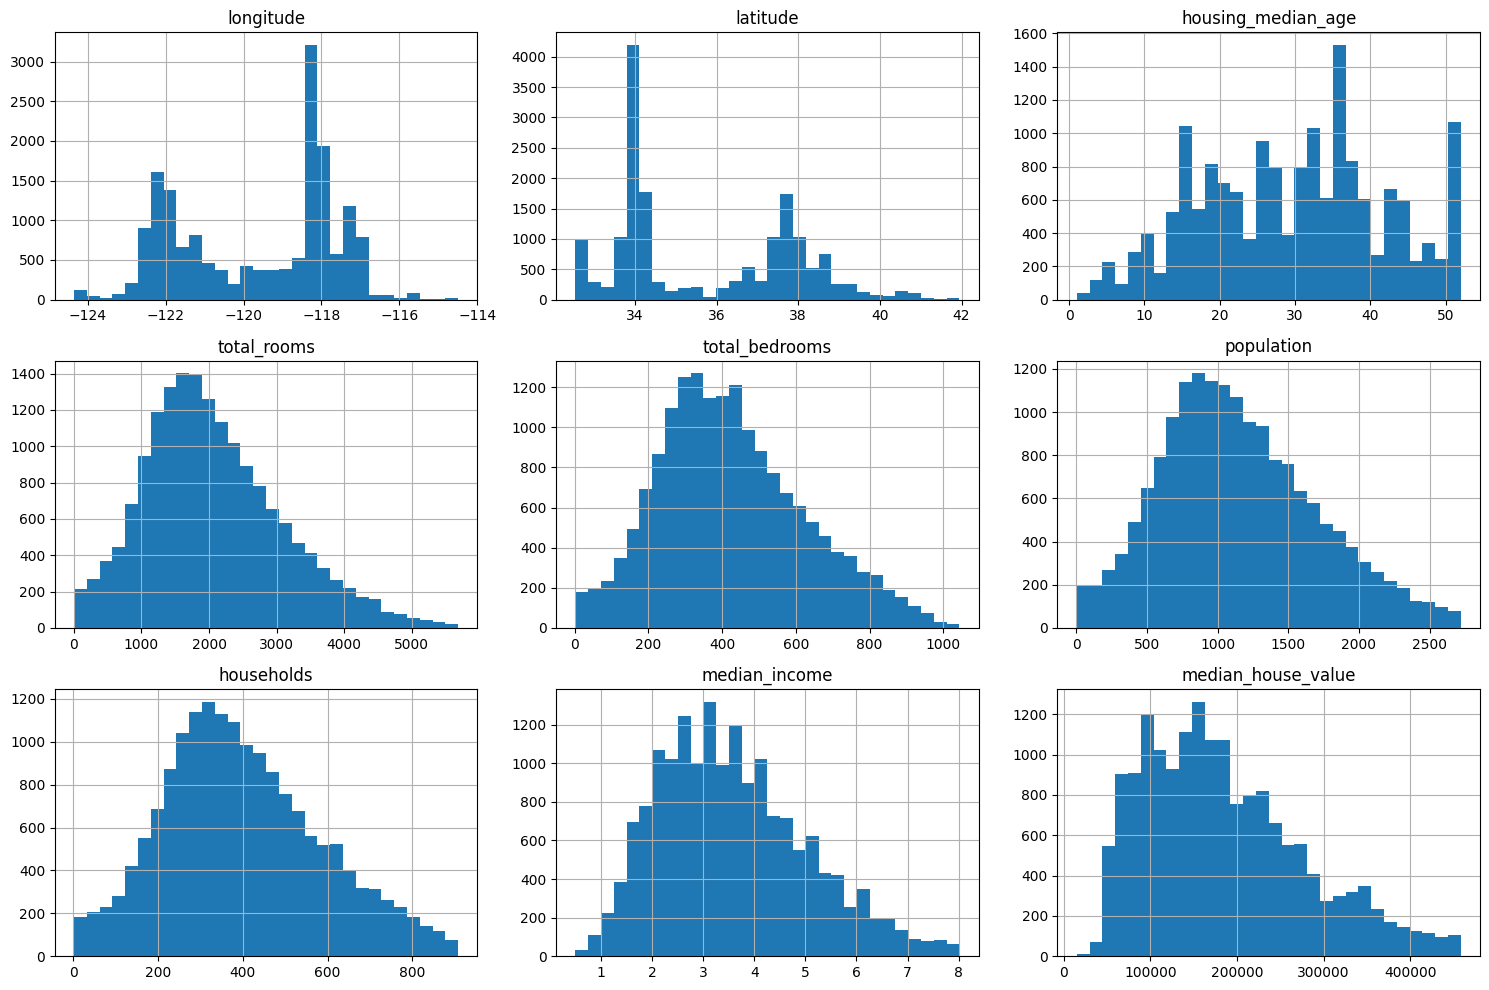

In [16]:
df[numeric_features].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.savefig('../logs/distributions.png')
plt.show()


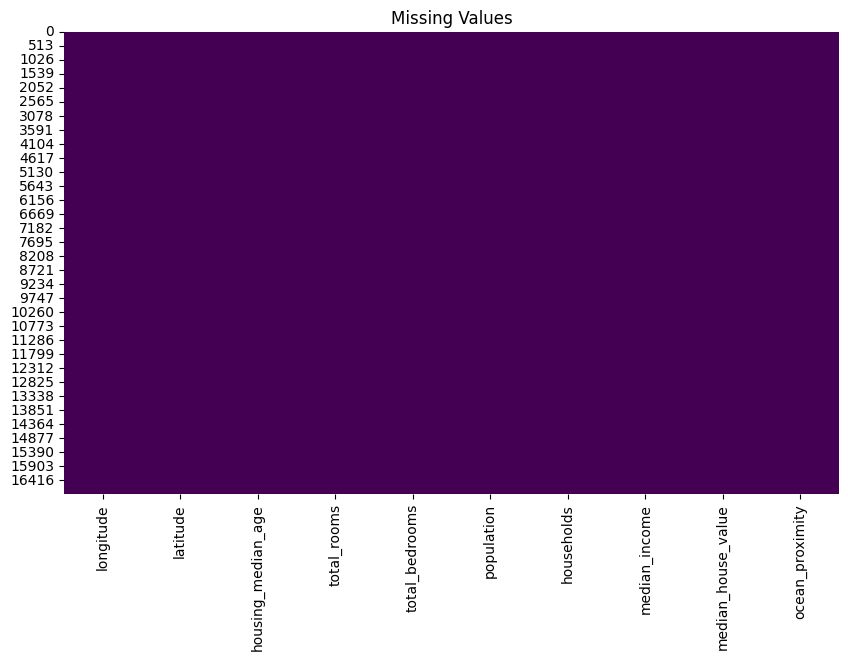

In [17]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values')
plt.savefig('../logs/missing_values.png')
plt.show()

In [ ]:
target_col = 'total_rooms'
if target_col in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=target_col, data=df, palette='Set2')
    plt.title('Target Distribution')
    plt.show()
else:
    print(f"Column '{target_col}' not found in the dataset.")

/tmp/ipykernel_886308/2664727202.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette='Set2')


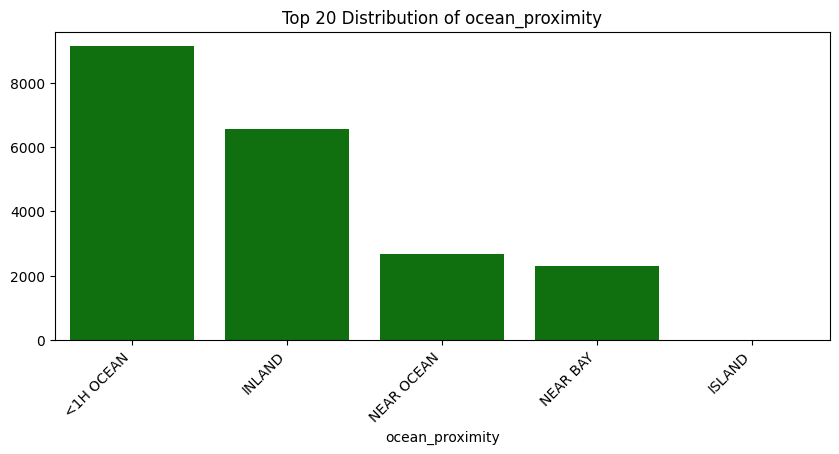

In [ ]:
top_n = 20

for col in categorical_features:
    plt.figure(figsize=(10, 4))
    top_values = df[col].value_counts().nlargest(top_n) 
    sns.barplot(x=top_values.index, y=top_values.values, color='green')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Top {top_n} Distribution of {col}')
    plt.show()

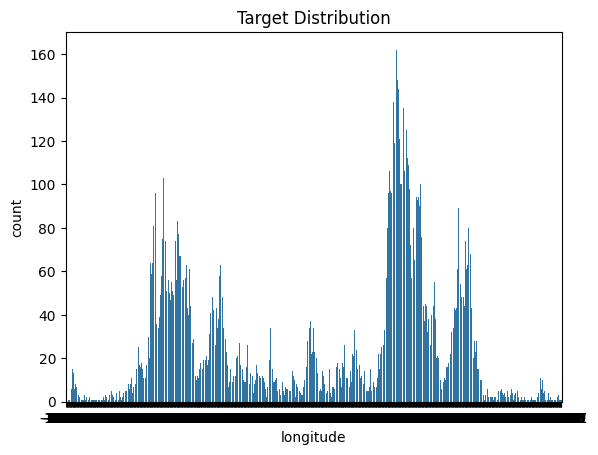

In [ ]:
sns.countplot(x=df["longitude"])
plt.title("Target Distribution")
plt.show()